In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
train.shape

(24000, 25)

In [5]:
test.shape


(6000, 24)

In [6]:
train.head()

,client_id,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,CC_0000F52C3717,50000,2,1,2,26,1,2,0,0,...,39475,40187,40992,2200,1962,1562,1500,1474,2300,0
1,CC_0008C4E44BB9,150000,2,1,2,26,-1,-1,-1,0,...,18400,1527,1527,0,18600,0,1527,0,0,0
2,CC_000B4B1BEDF6,450000,2,2,1,38,-2,-2,-2,-2,...,17255,17515,0,15008,1200,5255,4566,0,3648,0
3,CC_000D492CE7AD,230000,2,2,2,30,0,0,0,0,...,108826,100862,92481,6000,6000,4000,4000,3500,4000,0
4,CC_000DCFA992C4,160000,2,2,2,34,-1,-1,-1,-1,...,13780,12297,12752,24000,8000,13780,12300,12752,6000,0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  24000 non-null  object
 1   LIMIT_BAL  24000 non-null  int64 
 2   SEX        24000 non-null  int64 
 3   EDUCATION  24000 non-null  int64 
 4   MARRIAGE   24000 non-null  int64 
 5   AGE        24000 non-null  int64 
 6   PAY_0      24000 non-null  int64 
 7   PAY_2      24000 non-null  int64 
 8   PAY_3      24000 non-null  int64 
 9   PAY_4      24000 non-null  int64 
 10  PAY_5      24000 non-null  int64 
 11  PAY_6      24000 non-null  int64 
 12  BILL_AMT1  24000 non-null  int64 
 13  BILL_AMT2  24000 non-null  int64 
 14  BILL_AMT3  24000 non-null  int64 
 15  BILL_AMT4  24000 non-null  int64 
 16  BILL_AMT5  24000 non-null  int64 
 17  BILL_AMT6  24000 non-null  int64 
 18  PAY_AMT1   24000 non-null  int64 
 19  PAY_AMT2   24000 non-null  int64 
 20  PAY_AMT3   24000 non-null  i

## Dataset Overview

The training dataset contains 24,000 customers and the test dataset contains 6,000 customers. The training data contains 25 columns, including the `default` target. All training columns contain 24,000 non-null observations, indicating that there are no missing values.

## Check Duplicates

In [21]:
#2. Check duplicates
train.duplicated().sum()


np.int64(0)

In [22]:
test.duplicated().sum()

np.int64(0)

In [23]:
# Check duplicated ID's
train["client_id"].duplicated().sum()

np.int64(0)

## Target Distribution

In [8]:
train['default'].value_counts()

default
0    18691
1     5309
Name: count, dtype: int64

In [10]:
train["default"].value_counts(normalize=True)*100

default
0    77.879167
1    22.120833
Name: proportion, dtype: float64

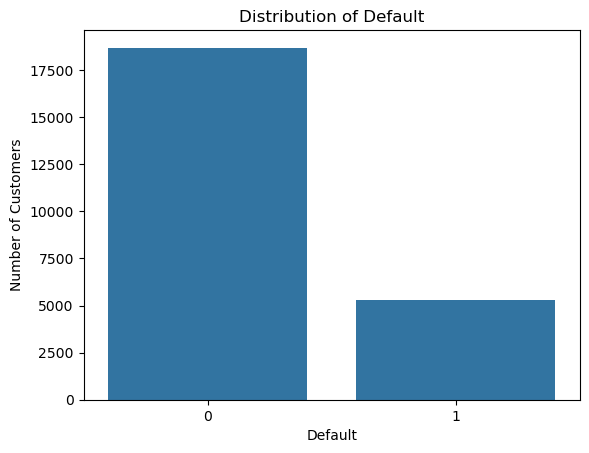

In [24]:
sns.countplot(data=train, x="default")
plt.title("Distribution of Default")
plt.xlabel("Default")
plt.ylabel("Number of Customers")
plt.show()

### Interpretation

The target is moderately imbalanced. Approximately 77.88% of customers did not default, while 22.12% defaulted. Therefore, accuracy alone would not be an appropriate metric for evaluating the model. Since the competition uses binary Log Loss, our model should focus on producing accurate and well-calibrated probabilities.

## Numerical feature summary

In [25]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,24000.0,167608.736667,130130.702503,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,24000.0,1.601792,0.489539,1.0,1.00,2.0,2.00,2.0
EDUCATION,24000.0,1.850708,0.795213,0.0,1.00,2.0,2.00,6.0
MARRIAGE,24000.0,1.547958,0.521898,0.0,1.00,2.0,2.00,3.0
AGE,24000.0,35.540708,9.255129,21.0,28.00,34.0,42.00,75.0
PAY_0,24000.0,-0.019875,1.125514,-2.0,-1.00,0.0,0.00,8.0
PAY_2,24000.0,-0.137042,1.199960,-2.0,-1.00,0.0,0.00,8.0
PAY_3,24000.0,-0.168542,1.202787,-2.0,-1.00,0.0,0.00,8.0
PAY_4,24000.0,-0.225000,1.172113,-2.0,-1.00,0.0,0.00,8.0
PAY_5,24000.0,-0.269667,1.135635,-2.0,-1.00,0.0,0.00,8.0


## Check the categorical/code variables

In [26]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print("\n", col)
    print(train[col].value_counts().sort_index())


 SEX
SEX
1     9557
2    14443
Name: count, dtype: int64

 EDUCATION
EDUCATION
0       10
1     8551
2    11151
3     3911
4       97
5      237
6       43
Name: count, dtype: int64

 MARRIAGE
MARRIAGE
0       42
1    11019
2    12685
3      254
Name: count, dtype: int64


## Check repayment-status codes

In [31]:
cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
for col in cols:
    print(train[col].value_counts().sort_index() )
    

PAY_0
-2     2241
-1     4561
 0    11739
 1     2944
 2     2147
 3      262
 4       56
 5       18
 6       11
 7        6
 8       15
Name: count, dtype: int64
PAY_2
-2     3061
-1     4848
 0    12543
 1       23
 2     3137
 3      261
 4       78
 5       23
 6        9
 7       16
 8        1
Name: count, dtype: int64
PAY_3
-2     3322
-1     4747
 0    12540
 1        4
 2     3075
 3      187
 4       64
 5       18
 6       19
 7       21
 8        3
Name: count, dtype: int64
PAY_4
-2     3538
-1     4547
 0    13096
 1        2
 2     2541
 3      144
 4       53
 5       28
 6        4
 7       45
 8        2
Name: count, dtype: int64
PAY_5
-2     3688
-1     4425
 0    13503
 2     2111
 3      144
 4       65
 5       15
 6        4
 7       44
 8        1
Name: count, dtype: int64
PAY_6
-2     3984
-1     4571
 0    12989
 2     2206
 3      143
 4       43
 5       11
 6       18
 7       34
 8        1
Name: count, dtype: int64


## AGE distribution

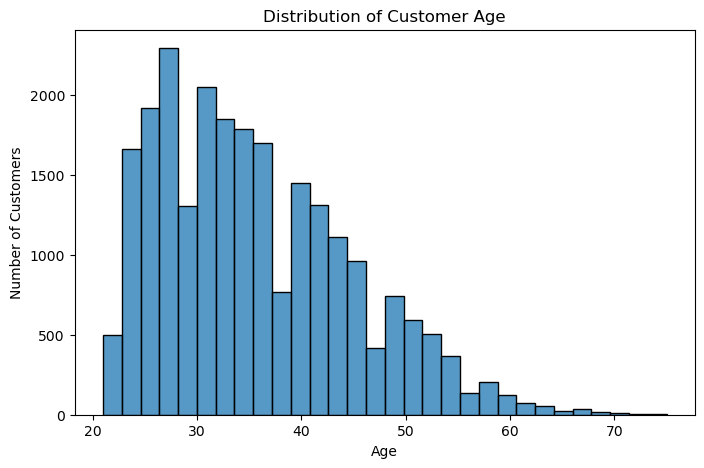

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(data=train, x="AGE", bins=30)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

## Credit limit

In [12]:
train["LIMIT_BAL"].describe()

count      24000.000000
mean      167608.736667
std       130130.702503
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

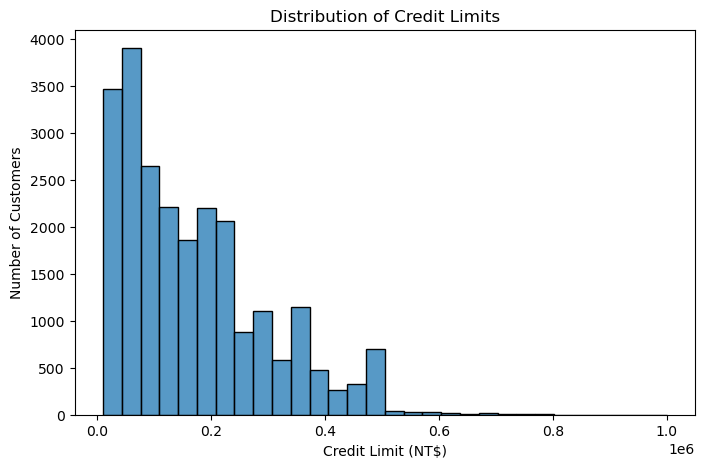

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=train, x="LIMIT_BAL", bins=30)
plt.xlabel("Credit Limit (NT$)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Credit Limits")
plt.show()

### Interpretation

The distribution of credit limits is right-skewed. Most customers have relatively lower credit limits, mainly below NT$200,000, while only a small number of customers have very high credit limits. The credit limit ranges from NT$10,000 to NT$1,000,000.

In [17]:
# How is Credit_Limit realted to Default
train.groupby("LIMIT_BAL")["default"].mean()

LIMIT_BAL
10000      0.401535
16000      0.000000
20000      0.361181
30000      0.345708
40000      0.421622
             ...   
750000     0.000000
760000     0.000000
780000     0.000000
800000     0.000000
1000000    0.000000
Name: default, Length: 80, dtype: float64

In [18]:
#how many customers are in each credit-limit group.
train.groupby("LIMIT_BAL")["default"].agg(["count", "mean"])

,count,mean
LIMIT_BAL,,
10000,391,0.401535
16000,2,0.000000
20000,1592,0.361181
30000,1293,0.345708
40000,185,0.421622
...,...,...
750000,4,0.000000
760000,1,0.000000
780000,1,0.000000


In [35]:
# create credit limit groups
limit_group = pd.cut(
    train["LIMIT_BAL"],
    bins=[0,10000,20000,30000,40000, 50000, 100000, 200000, 300000, 500000, float("inf")],
    labels=["10k","10-20K","20-30K","30-40K","40-50K", "50–100k", "100–200k", "200–300k", "300–500k", "500k+"]
)

In [36]:
train.groupby(limit_group, observed=False)["default"].agg(["count", "mean"])

,count,mean
LIMIT_BAL,,
10k,391,0.401535
10-20K,1594,0.360728
20-30K,1293,0.345708
30-40K,185,0.421622
40-50K,2686,0.255026
50–100k,3861,0.257964
100–200k,6279,0.195413
200–300k,4052,0.161895
300–500k,3493,0.133982


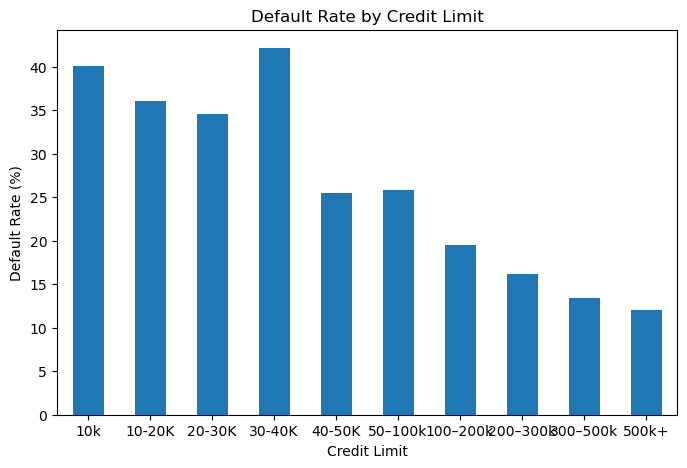

In [37]:
# Credit limit vs default graph
limit_default = train.groupby(
    limit_group, observed=False
)["default"].mean() * 100

limit_default.plot(kind="bar", figsize=(8,5))

plt.title("Default Rate by Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Interpretation

The default rate generally decreases as the credit limit increases. Lower credit-limit groups have substantially higher observed default rates, while customers with credit limits above NT$200,000 generally have lower default rates. This suggests that `LIMIT_BAL` may be an informative predictor of default risk. However, this is an association rather than evidence that credit limit directly causes or prevents default.

## Demographics vs default

In [38]:
train.groupby("SEX")["default"].agg(["count","mean"])

,count,mean
SEX,,
1,9557,0.239615
2,14443,0.209029


### SEX vs Default

Default rates differ between the two SEX categories, with approximately 24.0% in category 1 and 20.9% in category 2. This suggests that SEX may contain some predictive information, although the difference is relatively modest.

In [39]:
train.groupby("EDUCATION")["default"].agg(["count", "mean"])

,count,mean
EDUCATION,,
0,10,0.000000
1,8551,0.194129
2,11151,0.236660
3,3911,0.251087
4,97,0.061856
5,237,0.063291
6,43,0.162791


In [40]:
train.groupby("MARRIAGE")["default"].agg(["count", "mean"])

,count,mean
MARRIAGE,,
0,42,0.119048
1,11019,0.233960
2,12685,0.209696
3,254,0.259843


## Repayment history vs default

In [41]:
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
for col in pay_cols:
    print("\n", col)
    print(train.groupby(col)["default"].mean().round(3))


 PAY_0
PAY_0
-2    0.134
-1    0.164
 0    0.128
 1    0.343
 2    0.691
 3    0.752
 4    0.643
 5    0.500
 6    0.545
 7    0.667
 8    0.600
Name: default, dtype: float64

 PAY_2
PAY_2
-2    0.184
-1    0.158
 0    0.159
 1    0.174
 2    0.556
 3    0.625
 4    0.526
 5    0.565
 6    0.667
 7    0.625
 8    0.000
Name: default, dtype: float64

 PAY_3
PAY_3
-2    0.184
-1    0.155
 0    0.173
 1    0.250
 2    0.520
 3    0.594
 4    0.578
 5    0.500
 6    0.632
 7    0.857
 8    0.667
Name: default, dtype: float64

 PAY_4
PAY_4
-2    0.189
-1    0.159
 0    0.184
 1    0.500
 2    0.523
 3    0.625
 4    0.642
 5    0.571
 6    0.250
 7    0.822
 8    0.500
Name: default, dtype: float64

 PAY_5
PAY_5
-2    0.193
-1    0.159
 0    0.190
 2    0.544
 3    0.611
 4    0.615
 5    0.667
 6    0.750
 7    0.818
 8    1.000
Name: default, dtype: float64

 PAY_6
PAY_6
-2    0.199
-1    0.166
 0    0.189
 2    0.510
 3    0.650
 4    0.628
 5    0.545
 6    0.722
 7    0.824
 8    1.00

### Interpretation 
### Repayment Status vs Default

Repayment-status variables show a strong relationship with default risk. For example, the observed default rate for `PAY_0` increases substantially from 12.8% for code 0 to 34.3% for code 1 and above 69% for codes 2 and 3. Similar patterns are visible for `PAY_2`. This suggests that recent repayment behaviour is likely to be one of the strongest predictors of default. Categories with very few observations should be interpreted cautiously.

## Bill amounts

In [42]:
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

train[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,24000.0,51190.568667,73864.760063,-165580.0,3481.75,22435.5,67002.50,964511.0
BILL_AMT2,24000.0,49051.114833,71235.885503,-69777.0,2935.00,21190.5,63635.00,983931.0
BILL_AMT3,24000.0,46859.046750,69551.171536,-157264.0,2570.50,20010.5,59857.00,1664089.0
BILL_AMT4,24000.0,43175.799292,64534.910992,-65167.0,2300.75,18932.0,54341.50,891586.0
BILL_AMT5,24000.0,40271.754333,60980.478739,-61372.0,1710.25,18021.5,49937.50,927171.0
BILL_AMT6,24000.0,38743.087125,59707.335820,-209051.0,1206.00,16926.5,48904.75,961664.0


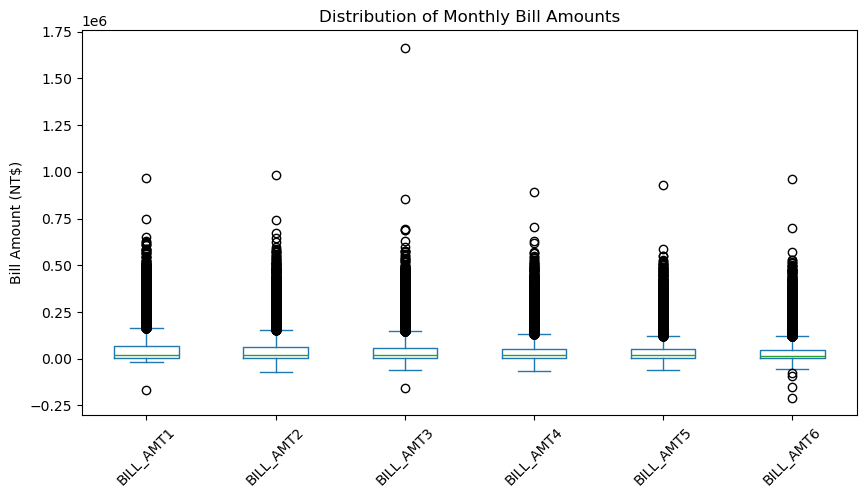

In [43]:
train[bill_cols].plot(
    kind="box",
    figsize=(10,5)
)

plt.title("Distribution of Monthly Bill Amounts")
plt.ylabel("Bill Amount (NT$)")
plt.xticks(rotation=45)
plt.show()

In [44]:
bill_bins = pd.cut(
    train["BILL_AMT1"],
    bins=[-float("inf"), 0, 10000, 50000, 100000, 200000, float("inf")],
    labels=["≤0", "0–10k", "10–50k", "50–100k", "100–200k", "200k+"]
)

In [45]:
train.groupby(bill_bins, observed=False)["default"].agg(["count", "mean"])

,count,mean
BILL_AMT1,,
≤0,2111,0.249171
0–10k,6578,0.211614
10–50k,7740,0.235271
50–100k,3665,0.214734
100–200k,2691,0.193980
200k+,1215,0.214815


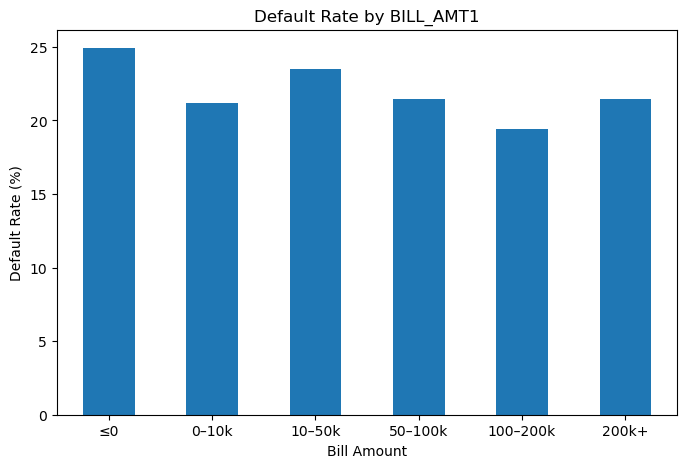

In [46]:
bill_default = train.groupby(
    bill_bins, observed=False
)["default"].mean() * 100

bill_default.plot(kind="bar", figsize=(8,5))

plt.title("Default Rate by BILL_AMT1")
plt.xlabel("Bill Amount")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Bill amounts have huge variation and many extreme values, but the binned default rates don't show a dramatic pattern.

## Payment amounts

In [47]:
pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

train[pay_amt_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,24000.0,5711.710125,17155.309436,0.0,992.50,2100.0,5004.00,873552.0
PAY_AMT2,24000.0,5955.190125,24350.211213,0.0,780.00,2000.0,5000.00,1684259.0
PAY_AMT3,24000.0,5262.745792,18426.028570,0.0,390.00,1800.0,4500.00,896040.0
PAY_AMT4,24000.0,4853.362792,15752.040523,0.0,298.75,1500.0,4001.25,621000.0
PAY_AMT5,24000.0,4749.935125,14873.057360,0.0,212.75,1500.0,4005.00,417990.0
PAY_AMT6,24000.0,5161.937458,17925.431411,0.0,100.00,1500.0,4000.00,528666.0


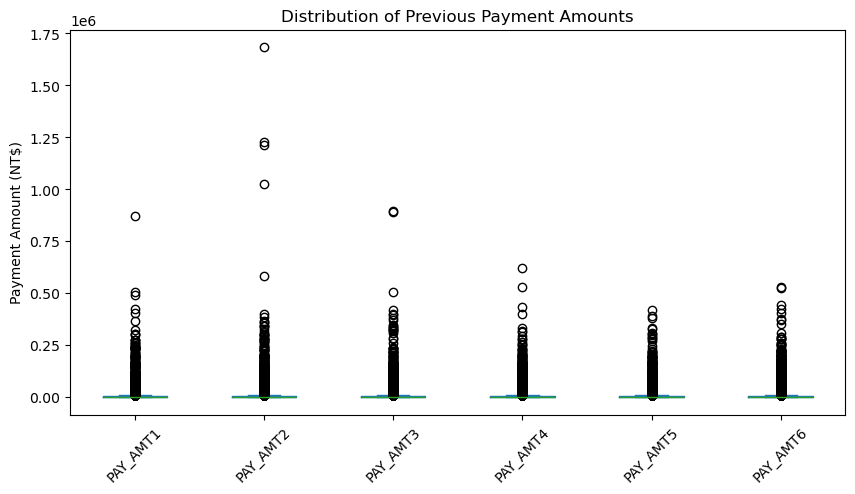

In [48]:
train[pay_amt_cols].plot(
    kind="box",
    figsize=(10,5)
)

plt.title("Distribution of Previous Payment Amounts")
plt.ylabel("Payment Amount (NT$)")
plt.xticks(rotation=45)
plt.show()

In [49]:
payment_group = pd.cut(
    train["PAY_AMT1"],
    bins=[-float("inf"), 0, 5000, 10000, 30000, 50000, 100000, float("inf")],
    labels=["0", "0–5k", "5–10k", "10–30k", "30–50k", "50–100k", "100k+"]
)

In [50]:
train.groupby(payment_group, observed=False)["default"].agg(["count", "mean"])

,count,mean
PAY_AMT1,,
0,4223,0.355435
0–5k,13752,0.214151
5–10k,3406,0.155021
10–30k,1950,0.144103
30–50k,289,0.083045
50–100k,256,0.085938
100k+,124,0.064516


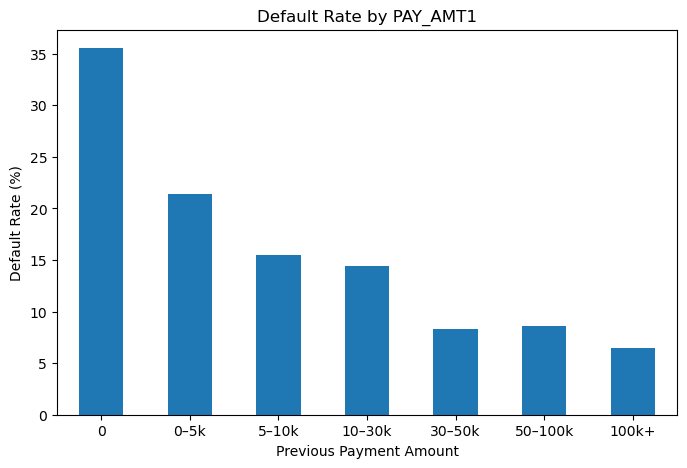

In [51]:
payment_default = train.groupby(
    payment_group, observed=False
)["default"].mean() * 100

payment_default.plot(kind="bar", figsize=(8,5))

plt.title("Default Rate by PAY_AMT1")
plt.xlabel("Previous Payment Amount")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Previous Payment Amount vs Default

Previous payment amount shows a clear association with default risk. Customers with no previous payment have an observed default rate of approximately 35.5%, compared with around 6.5% for customers who paid more than NT$100,000. Overall, default rates generally decrease as previous payment amounts increase. However, this represents an association rather than a causal relationship. Payment amounts are also highly skewed, with several extreme values.

In [53]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  24000 non-null  object
 1   LIMIT_BAL  24000 non-null  int64 
 2   SEX        24000 non-null  int64 
 3   EDUCATION  24000 non-null  int64 
 4   MARRIAGE   24000 non-null  int64 
 5   AGE        24000 non-null  int64 
 6   PAY_0      24000 non-null  int64 
 7   PAY_2      24000 non-null  int64 
 8   PAY_3      24000 non-null  int64 
 9   PAY_4      24000 non-null  int64 
 10  PAY_5      24000 non-null  int64 
 11  PAY_6      24000 non-null  int64 
 12  BILL_AMT1  24000 non-null  int64 
 13  BILL_AMT2  24000 non-null  int64 
 14  BILL_AMT3  24000 non-null  int64 
 15  BILL_AMT4  24000 non-null  int64 
 16  BILL_AMT5  24000 non-null  int64 
 17  BILL_AMT6  24000 non-null  int64 
 18  PAY_AMT1   24000 non-null  int64 
 19  PAY_AMT2   24000 non-null  int64 
 20  PAY_AMT3   24000 non-null  i

## MODEL

### Create X and y


In [54]:
X = train.drop(columns=["default", "client_id"])
y = train["default"]

In [56]:
# Split into training and validation
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [57]:
# Tell python which columns are categorical
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

In [58]:
# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [59]:
# Add Logistic Regression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [60]:
# Train the model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
# Predict probabilities
y_pred = model.predict_proba(X_valid)[:, 1]

In [62]:
y_pred[:10]

array([0.1580205 , 0.17133373, 0.10588721, 0.18135462, 0.08746234,
       0.57537816, 0.09927049, 0.12097203, 0.10295539, 0.71841973])

In [63]:
# Calculate Log Loss
from sklearn.metrics import log_loss

baseline_logloss = log_loss(y_valid, y_pred)

print("Baseline Log Loss:", baseline_logloss)

Baseline Log Loss: 0.44892872187199706


## TRAIN MODEL ON ALL 24000 CUSTOMERS AND THEN PREDICT THE OUTPUT FOR CUSTOMERS IN TEST DATA

In [64]:
# Load test.csv
test = pd.read_csv("test.csv")

test.head()

,client_id,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,CC_0012A082B7B7,30000,2,3,3,60,-1,-1,-2,-2,...,-581,-2054,1473,14510,0,0,0,5000,14510,0
1,CC_0012BC27DFB6,70000,1,2,1,29,0,0,0,0,...,66460,46988,43530,44804,3000,3000,2000,2500,2000,2000
2,CC_001563B2143D,150000,2,2,1,34,-2,-2,-2,-2,...,1139,2246,5435,466,1801,1139,2246,5435,466,316
3,CC_001B46930B6F,80000,2,1,2,28,0,0,0,0,...,73888,75345,75040,75211,3200,3500,3300,2800,2900,2900
4,CC_001D771E1C9F,220000,2,1,1,40,0,0,0,0,...,61655,61855,64966,66942,8000,3000,3000,5000,3000,3000


In [65]:
test.shape

(6000, 24)

In [66]:
# Prepare the test features
X_test = test.drop(columns=["client_id"])

In [67]:
# Train our model on ALL 24,000
model.fit(X, y)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
#Predict probabilities
test_pred = model.predict_proba(X_test)[:, 1]

In [69]:
test_pred[:10]

array([0.25003879, 0.15810727, 0.18020603, 0.11963772, 0.10328737,
       0.03628093, 0.21408514, 0.05584127, 0.73798763, 0.11007118])

In [70]:
test.columns

Index(['client_id', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
       'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [75]:
# Load sample submission format
sample = pd.read_csv("sample_submission.csv")
sample.head()

,client_id,default_probability
0,CC_0012A082B7B7,0.221208
1,CC_0012BC27DFB6,0.221208
2,CC_001563B2143D,0.221208
3,CC_001B46930B6F,0.221208
4,CC_001D771E1C9F,0.221208


In [77]:
# Put predictions into the prediction column
sample["default_probability"] = test_pred
submission = sample[["client_id", "default_probability"]]

In [78]:
# Save
submission.to_csv("submission_baseline.csv", index=False)


In [79]:
# Check
submission.head()

,client_id,default_probability
0,CC_0012A082B7B7,0.250039
1,CC_0012BC27DFB6,0.158107
2,CC_001563B2143D,0.180206
3,CC_001B46930B6F,0.119638
4,CC_001D771E1C9F,0.103287


In [82]:
submission = pd.DataFrame({
    "client_id": test["client_id"],
    "default_probability": test_pred
})

submission.to_csv("submission_baseline.csv", index=False)

print(submission.shape)
print(submission.columns.tolist())

(6000, 2)
['client_id', 'default_probability']


In [83]:
submission.to_csv(
    r"C:\Users\Ria\Downloads\submission_baseline.csv",
    index=False
)